In [1]:
import pandas as pd
import neurokit2 as nk


data = pd.read_parquet('ecg_log_2026-02-21_002056.parquet')
window_size = 5 * 60 * 250
chunks = [data[i:i + window_size] for i in range(0, len(data), window_size)]

ecg = chunks[0]
ecg_signals, info = nk.ecg_process(ecg_signal=ecg["ecg"], sampling_rate=250)

## ECG预处理与画图
- `nk.ecg_process(ecg_signal, sampling_rate)`
- `nk.ecg_plot(ecg_signal, info)`

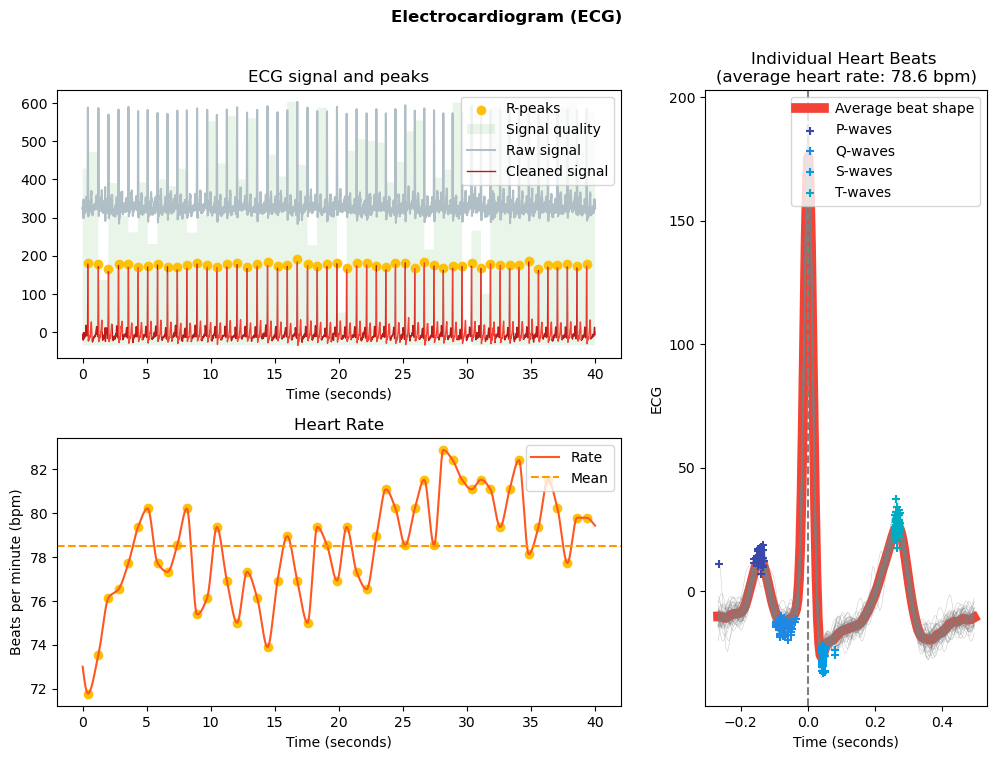

In [ ]:
import matplotlib.pyplot as plt

#fig = plt.figure()
nk.ecg_plot(ecg_signals[60000:70000], info)

fig = plt.gcf()
fig.subplots_adjust(wspace=0.2, hspace=0.3)
fig.set_figwidth(12)
fig.set_figheight(8)

axes = fig.get_axes()
title_2 = axes[2].get_title()
str_idx = title_2.find('(')
axes[2].set_title(title_2[:str_idx] + '\n' + title_2[str_idx:])
plt.savefig('neuro_kit_2_test1.jpg', dpi=300, bbox_inches='tight')

In [4]:
d = {123:info}
df = pd.DataFrame(d).T
df['record_id'] = df.index
df = df[['record_id'] + list(df.columns[:-1])]
df.to_csv('test.csv')

In [5]:
df

,record_id,method_peaks,method_fixpeaks,ECG_R_Peaks,ECG_R_Peaks_Uncorrected,ECG_fixpeaks_ectopic,ECG_fixpeaks_missed,ECG_fixpeaks_extra,ECG_fixpeaks_longshort,ECG_fixpeaks_method,...,ECG_P_Peaks,ECG_P_Onsets,ECG_P_Offsets,ECG_Q_Peaks,ECG_R_Onsets,ECG_R_Offsets,ECG_S_Peaks,ECG_T_Peaks,ECG_T_Onsets,ECG_T_Offsets
123,123,neurokit,None,"[233, 429, 622, 808, 994, 1181, 1363, 1531, 17...","[233, 429, 622, 808, 994, 1181, 1363, 1531, 17...",[],[],[],"[272, 393]",kubios,...,"[196, 392, 585, 771, 957, 1145, 1327, 1495, 16...","[185, 381, 575, 761, 946, 1133, 1316, 1483, 16...","[211, 406, 601, 787, 973, 1162, 1341, 1507, 17...","[213, 413, 602, 793, 974, 1163, 1344, 1509, 17...","[199, 409, 592, 774, 964, 1152, 1330, 1496, 16...","[248, 444, 637, 823, 1007, 1196, 1377, 1545, 1...","[244, 440, 633, 818, 1004, 1192, 1373, 1541, 1...","[295, 491, 684, 869, 1056, 1244, 1425, 1592, 1...","[275, 474, 670, 853, 1047, 1220, 1406, 1562, 1...","[314, 509, 703, 886, 1074, 1261, 1442, 1609, 1..."


In [8]:
df['record_id']

123    123
Name: record_id, dtype: int64

In [65]:
for key in info.keys():
    print(key)

method_peaks
method_fixpeaks
ECG_R_Peaks
ECG_R_Peaks_Uncorrected
ECG_fixpeaks_ectopic
ECG_fixpeaks_missed
ECG_fixpeaks_extra
ECG_fixpeaks_longshort
ECG_fixpeaks_method
ECG_fixpeaks_rr
ECG_fixpeaks_drrs
ECG_fixpeaks_mrrs
ECG_fixpeaks_s12
ECG_fixpeaks_s22
ECG_fixpeaks_c1
ECG_fixpeaks_c2
sampling_rate
ECG_P_Peaks
ECG_P_Onsets
ECG_P_Offsets
ECG_Q_Peaks
ECG_R_Onsets
ECG_R_Offsets
ECG_S_Peaks
ECG_T_Peaks
ECG_T_Onsets
ECG_T_Offsets


## 处理整晚数据

In [78]:
import numpy as np
def process_ecg_night(
    ecg,
    fs=250,
    chunk_sec=600,        # 10 min
    overlap_sec=5,        # 5 s padding on both sides
    min_rr=0.30,          # 300 ms
    max_rr=2.00           # 2000 ms
):
    n = len(ecg)
    chunk = int(chunk_sec * fs)
    pad = int(overlap_sec * fs)

    all_rpeaks = []
    all_rr = []

    start = 0
    while start < n:
        # padded window
        a = max(0, start - pad)
        b = min(n, start + chunk + pad)

        seg = ecg[a:b]

        # fast path: only peaks + cleaning; avoid full ecg_process if you want
        # Option A: ecg_process (richer but heavier)
        signals, info = nk.ecg_process(seg, sampling_rate=fs)

        r = np.asarray(info["ECG_R_Peaks"], dtype=int)

        # keep only peaks in the core region (exclude padding)
        core_l = start - a
        core_r = min(start + chunk, n) - a
        r = r[(r >= core_l) & (r < core_r)]

        # convert to global index
        r_global = r + a
        all_rpeaks.append(r_global)

        start += chunk

    rpeaks = np.unique(np.concatenate(all_rpeaks)) if all_rpeaks else np.array([], dtype=int)

    # RR (seconds) + physical sanity gate
    if len(rpeaks) >= 2:
        rr = np.diff(rpeaks) / fs
        ok = (rr >= min_rr) & (rr <= max_rr)
        # keep only rr that look physiological
        all_rr = rr[ok]
    else:
        all_rr = np.array([])

    return rpeaks, all_rr

In [100]:
rpeaks, all_rr = process_ecg_night(data['ecg'])
print(len(rpeaks) - len(all_rr))
np.save('rpeaks.npy', rpeaks)
np.save('all_rr.npy', all_rr)

33


In [94]:

def hrv_metrics_from_rr(rr_s, *, unit="s"):
    """
    Compute basic HRV metrics from RR intervals.

    Parameters
    ----------
    rr_s : array-like or pd.Series
        RR intervals. Default expected unit is seconds.
        Can contain NaN; will be dropped.
    unit : {"s","ms"}
        Unit of rr_s.

    Returns
    -------
    metrics : dict
        Keys include:
        - n_beats (int)
        - mean_rr_ms, median_rr_ms
        - mean_hr_bpm
        - sdnn_ms
        - rmssd_ms
        - pnn50_pct
        - poincare_sd1_ms, poincare_sd2_ms, sd1_sd2
    """
    rr = np.asarray(rr_s, dtype=float)
    rr = rr[~np.isnan(rr)]
    if rr.size < 3:
        raise ValueError("Need at least 3 RR intervals after NaN removal.")

    # Convert to seconds internally
    if unit == "ms":
        rr_sec = rr / 1000.0
    elif unit == "s":
        rr_sec = rr
    else:
        raise ValueError("unit must be 's' or 'ms'")

    rr_ms = rr_sec * 1000.0
    drr_ms = np.diff(rr_ms)

    mean_rr_ms = float(np.mean(rr_ms))
    median_rr_ms = float(np.median(rr_ms))
    mean_hr_bpm = float(60.0 / np.mean(rr_sec))

    # Time-domain
    sdnn_ms = float(np.std(rr_ms, ddof=1))
    rmssd_ms = float(np.sqrt(np.mean(drr_ms**2)))

    # pNN50
    pnn50_pct = float(100.0 * np.mean(np.abs(drr_ms) > 50.0))

    # Poincaré (standard definitions)
    # SD1 relates to short-term variability; SD2 to long-term.
    sd1_ms = float(np.sqrt(0.5) * np.std(drr_ms, ddof=1))
    sd2_ms = float(np.sqrt(2.0 * sdnn_ms**2 - 0.5 * np.std(drr_ms, ddof=1)**2))
    sd1_sd2 = float(sd1_ms / sd2_ms) if sd2_ms > 0 else np.nan

    return {
        "n_beats": int(rr_ms.size),
        "mean_rr_ms": mean_rr_ms,
        "median_rr_ms": median_rr_ms,
        "mean_hr_bpm": mean_hr_bpm,
        "sdnn_ms": sdnn_ms,
        "rmssd_ms": rmssd_ms,
        "pnn50_pct": pnn50_pct,
        "poincare_sd1_ms": sd1_ms,
        "poincare_sd2_ms": sd2_ms,
        "sd1_sd2": sd1_sd2,
    }


def add_poincare_ellipse(ax, mean_rr_ms, sd1_ms, sd2_ms, n_std=2.0, **kwargs):
    """
    Draw Poincaré ellipse centered at (mean_rr_ms, mean_rr_ms),
    with axes aligned to the identity line, using SD1/SD2.
    n_std controls ellipse size (e.g., 1, 2, 3).
    """
    # Parametric ellipse in SD2-SD1 coordinate frame
    theta = np.linspace(0, 2*np.pi, 400)
    a = n_std * sd2_ms  # along identity line
    b = n_std * sd1_ms  # perpendicular
    u = a * np.cos(theta)
    v = b * np.sin(theta)

    # Rotate back to (RRn, RRn+1) coordinates:
    # identity/perpendicular basis is rotated by 45 degrees
    x_ell = mean_rr_ms + (u - v) / np.sqrt(2)
    y_ell = mean_rr_ms + (u + v) / np.sqrt(2)

    ax.plot(x_ell, y_ell, **kwargs)

def get_dtime(timestamp):
    dt_object = datetime.datetime.fromtimestamp(timestamp)
    formatted_time = dt_object.strftime('%Y-%m-%d %H:%M:%S')
    return formatted_time

def get_dtime_nospace(timestamp):
    dt_object = datetime.datetime.fromtimestamp(timestamp)
    formatted_time = dt_object.strftime('%Y%m%d%H%M%S')
    return formatted_time

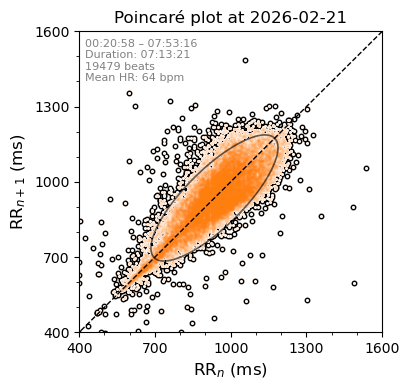

In [99]:
import datetime, time
from matplotlib import ticker

begin_time = data['time'].values[0]
end_time = data['time'].values[-1]
rr_clean = all_rr

metrics = hrv_metrics_from_rr(rr_clean, unit="s")
mean_rr_ms = np.mean(x)  # 你这里 x 已经是 rr_clean*1000 的 ms
sd1 = metrics["poincare_sd1_ms"]
sd2 = metrics["poincare_sd2_ms"]

x = rr_clean * 1000
diag = np.linspace(200, 1600)

fig = plt.figure(figsize=(4.2,4))
ax = plt.gca()

ax.scatter(x[:-1], x[1:], s=5, color="0.0", lw=2)
ax.scatter(x[:-1], x[1:], s=5, color="1.0", lw=0)
ax.scatter(x[:-1], x[1:], s=5, color="C1", lw=0, alpha=0.1)
ax.plot(diag, diag, color='k', linewidth=1, linestyle='--')

ax.set_xlabel("RR$_n$ (ms)", fontsize=12)
ax.set_ylabel("RR$_{n+1}$ (ms)", fontsize=12)

begin_date, begin_time = get_dtime(begin_time).split()
end_date, end_time = get_dtime(end_time).split()

if begin_date == end_date:
    ax.set_title(f"Poincaré plot at {begin_date}")
    ax.text(425, 1400,
        f"{begin_time} – {end_time}\nDuration: 07:13:21\n"
        f"{len(rr_clean)} beats\n"
        f"Mean HR: {60/np.mean(rr_clean):.0f} bpm",
        color='gray', fontsize=8
        )
else:
    ax.set_title(f"Poincaré plot\n{begin_date} – {end_date}", loc="left")
    ax.text(425, 1345,
        f"{begin_date} {begin_time} –\n{end_date} {end_time}\nDuration: 07:13:21\n"
        f"Beats: {len(rr_clean)}\n"
        f"Mean HR: {60/np.mean(rr_clean):.0f} bpm",
        color='gray', fontsize=8
        )

ax.set_xlim(400, 1600)
ax.set_ylim(400, 1600)
ax.xaxis.set_major_locator(ticker.LinearLocator(5))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(100))
ax.yaxis.set_major_locator(ticker.LinearLocator(5))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(100))



add_poincare_ellipse(
    ax, mean_rr_ms, sd1, sd2,
    n_std=2.0,
    color="k", linewidth=1.2, alpha=0.6
)

plt.tight_layout()

begin_time = ecg['time'].values[0]
begin_dtime = get_dtime_nospace(begin_time)
plt.savefig('ellipse_poincare_%s.jpg'%begin_dtime, dpi=500)
